Den her fejler fortsat lidt over dete hele ...

In [2]:
import numpy as np
from active_learning import run_active_learning
import matplotlib.pyplot as plt

<!-- scores, labeled_sizes, best_model, best_acc = run_active_learning(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=5,
    query_size=10,
    strategy="entropy",
    paradigm="active learning",
    batch_size=64,
    epochs=2,
    lr=1e-3,
    seed=42,
) -->

Uncertainty sampling
> Comparing entropy, least confidence and margin with just random sampling. With an initial training set of 100 images, we query 10 more images at every iteration by picking data points from the pool based on the three differetn strategies. 


=== Iteration 1/3 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/1  Loss: 4.617
Test accuracy: 0.1000

=== Iteration 2/3 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/1  Loss: 4.608
Test accuracy: 0.1429

=== Iteration 3/3 ===
Labeled set size: 120
Pool size:        49880
Epoch 1/1  Loss: 4.624
Test accuracy: 0.1609


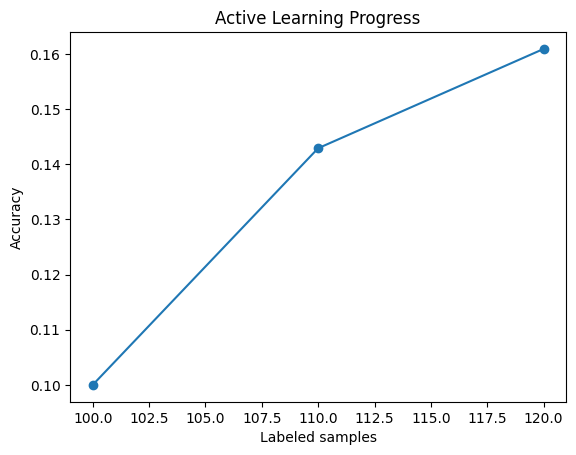

In [3]:
scores, labeled_sizes, best_model, best_acc = run_active_learning(
    n_initial_per_class=10,
    n_iterations=3,
    query_size=10,
    epochs=1,
)

plt.plot(labeled_sizes, scores, marker='o')
plt.xlabel("Labeled samples")
plt.ylabel("Accuracy")
plt.title("Active Learning Progress")
plt.show()


=== Iteration 1/10 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/1  Loss: 4.611
Test accuracy: 0.0991

=== Iteration 2/10 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/1  Loss: 4.615
Test accuracy: 0.1015

=== Iteration 3/10 ===
Labeled set size: 120
Pool size:        49880
Epoch 1/1  Loss: 4.622
Test accuracy: 0.1000

=== Iteration 4/10 ===
Labeled set size: 130
Pool size:        49870
Epoch 1/1  Loss: 6.859
Test accuracy: 0.1000

=== Iteration 5/10 ===
Labeled set size: 140
Pool size:        49860
Epoch 1/1  Loss: 6.926
Test accuracy: 0.1000

=== Iteration 6/10 ===
Labeled set size: 150
Pool size:        49850
Epoch 1/1  Loss: 6.907
Test accuracy: 0.1040

=== Iteration 7/10 ===
Labeled set size: 160
Pool size:        49840
Epoch 1/1  Loss: 6.890
Test accuracy: 0.1000

=== Iteration 8/10 ===
Labeled set size: 170
Pool size:        49830
Epoch 1/1  Loss: 6.896
Test accuracy: 0.1000

=== Iteration 9/10 ===
Labeled set size: 180
Pool size:        49820
Epoch 1/1 

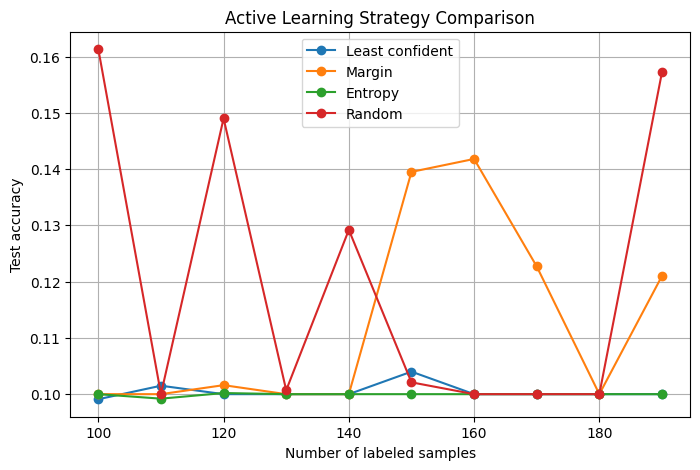

Best accuracies:
Least confident: 0.1040
Margin:          0.1418
Entropy:         0.1002
Random:          0.1613


In [ ]:
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Common settings
common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=10,
    query_size=10,
    batch_size=64,
    epochs=1,     # increase later if you want
    lr=1e-3,
    seed=42,
)

# Run active learning with the three uncertainty strategies
scores_lc, labeled_lc, best_model_lc, best_acc_lc = run_active_learning(
    strategy="least confident",
    paradigm="active learning",
    **common_kwargs
)

scores_margin, labeled_margin, best_model_margin, best_acc_margin = run_active_learning(
    strategy="margin",
    paradigm="active learning",
    **common_kwargs
)

scores_entropy, labeled_entropy, best_model_entropy, best_acc_entropy = run_active_learning(
    strategy="entropy",
    paradigm="active learning",
    **common_kwargs
)

# Run random sampling baseline
scores_random, labeled_random, best_model_random, best_acc_random = run_active_learning(
    paradigm="random",
    **common_kwargs
)

# Plot all curves together
plt.figure(figsize=(8, 5))

plt.plot(labeled_lc, scores_lc, marker='o', label='Least confident')
plt.plot(labeled_margin, scores_margin, marker='o', label='Margin')
plt.plot(labeled_entropy, scores_entropy, marker='o', label='Entropy')
plt.plot(labeled_random, scores_random, marker='o', label='Random')

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning Strategy Comparison")
plt.legend()
plt.grid(True)
plt.show()

# Print best accuracies too
print("Best accuracies:")
print(f"Least confident: {best_acc_lc:.4f}")
print(f"Margin:          {best_acc_margin:.4f}")
print(f"Entropy:         {best_acc_entropy:.4f}")
print(f"Random:          {best_acc_random:.4f}")

Running each iteration multiple times and computing averages to get more robust graphs that are less sensitive towards initialisation:


Running averaged experiment: Least confident
  Run 1/5

=== Iteration 1/10 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/1  Loss: 4.599
Test accuracy: 0.1022

=== Iteration 2/10 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/1  Loss: 4.621
Test accuracy: 0.1320

=== Iteration 3/10 ===
Labeled set size: 120
Pool size:        49880
Epoch 1/1  Loss: 4.617
Test accuracy: 0.1322

=== Iteration 4/10 ===
Labeled set size: 130
Pool size:        49870
Epoch 1/1  Loss: 6.936
Test accuracy: 0.1000

=== Iteration 5/10 ===
Labeled set size: 140
Pool size:        49860
Epoch 1/1  Loss: 6.922
Test accuracy: 0.1018

=== Iteration 6/10 ===
Labeled set size: 150
Pool size:        49850
Epoch 1/1  Loss: 6.942
Test accuracy: 0.1000

=== Iteration 7/10 ===
Labeled set size: 160
Pool size:        49840
Epoch 1/1  Loss: 6.909
Test accuracy: 0.1000

=== Iteration 8/10 ===
Labeled set size: 170
Pool size:        49830
Epoch 1/1  Loss: 6.931
Test accuracy: 0.1000

=== Iteration 9/10 ===


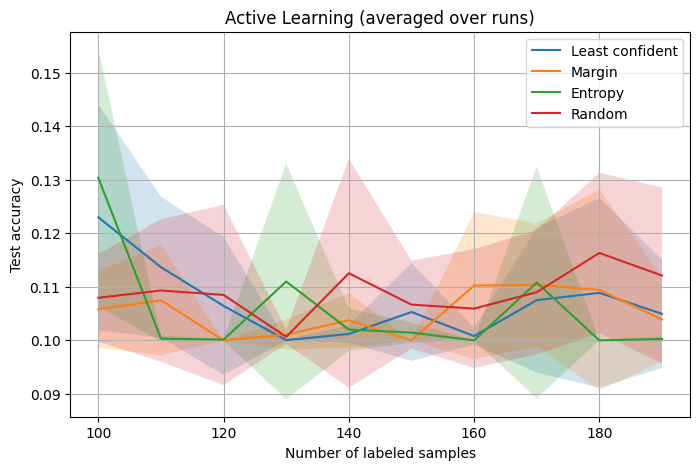

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 5          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 10

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=1,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()


Running averaged experiment: Least confident
  Run 1/3

=== Iteration 1/3 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/3  Loss: 4.632
Epoch 2/3  Loss: 4.505
Epoch 3/3  Loss: 4.353
Test accuracy: 0.2108

=== Iteration 2/3 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/3  Loss: 4.641
Epoch 2/3  Loss: 4.524
Epoch 3/3  Loss: 4.364
Test accuracy: 0.2088

=== Iteration 3/3 ===
Labeled set size: 120
Pool size:        49880
Epoch 1/3  Loss: 4.634
Epoch 2/3  Loss: 4.573
Epoch 3/3  Loss: 4.432
Test accuracy: 0.2101
  Run 2/3

=== Iteration 1/3 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/3  Loss: 4.696
Epoch 2/3  Loss: 4.524
Epoch 3/3  Loss: 4.419
Test accuracy: 0.1587

=== Iteration 2/3 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/3  Loss: 4.622
Epoch 2/3  Loss: 4.510
Epoch 3/3  Loss: 4.322
Test accuracy: 0.2216

=== Iteration 3/3 ===
Labeled set size: 120
Pool size:        49880
Epoch 1/3  Loss: 4.625
Epoch 2/3  Loss: 4.502
Epoch 3/3  Loss: 4.

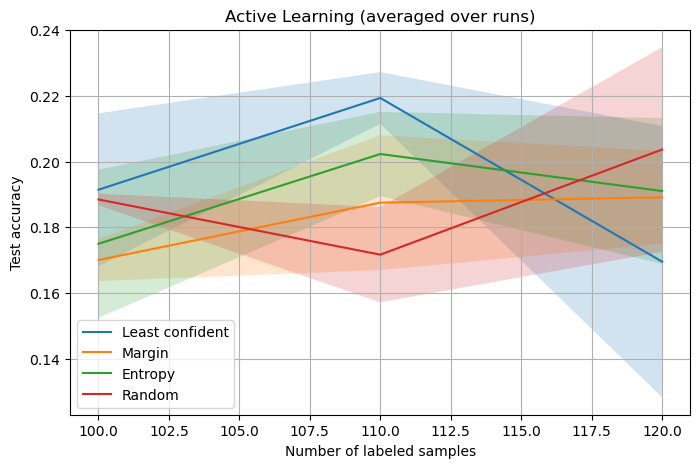

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 3          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 3

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=3,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()


Running averaged experiment: Least confident
  Run 1/3

=== Iteration 1/10 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/3  Loss: 4.655
Epoch 2/3  Loss: 4.513
Epoch 3/3  Loss: 4.366
Test accuracy: 0.1746

=== Iteration 2/10 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/3  Loss: 4.645
Epoch 2/3  Loss: 4.533
Epoch 3/3  Loss: 4.376
Test accuracy: 0.1958

=== Iteration 3/10 ===
Labeled set size: 120
Pool size:        49880
Epoch 1/3  Loss: 4.643
Epoch 2/3  Loss: 4.554
Epoch 3/3  Loss: 4.402
Test accuracy: 0.1971

=== Iteration 4/10 ===
Labeled set size: 130
Pool size:        49870
Epoch 1/3  Loss: 7.025
Epoch 2/3  Loss: 6.666
Epoch 3/3  Loss: 6.624
Test accuracy: 0.1004

=== Iteration 5/10 ===
Labeled set size: 140
Pool size:        49860
Epoch 1/3  Loss: 6.956
Epoch 2/3  Loss: 6.714
Epoch 3/3  Loss: 6.473
Test accuracy: 0.1896

=== Iteration 6/10 ===
Labeled set size: 150
Pool size:        49850
Epoch 1/3  Loss: 6.946
Epoch 2/3  Loss: 6.781
Epoch 3/3  Loss: 6.535


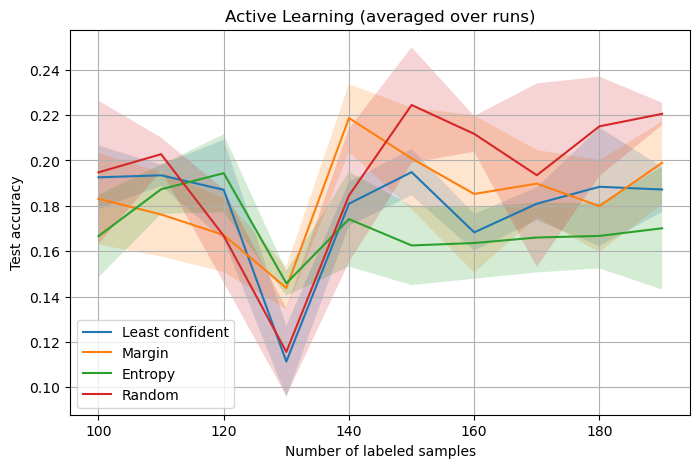

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 3          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 10

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=3,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()


Running averaged experiment: Least confident
  Run 1/3

=== Iteration 1/3 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/10  Loss: 4.653
Epoch 2/10  Loss: 4.529
Epoch 3/10  Loss: 4.424
Epoch 4/10  Loss: 4.305
Epoch 5/10  Loss: 4.077
Epoch 6/10  Loss: 3.815
Epoch 7/10  Loss: 3.537
Epoch 8/10  Loss: 3.251
Epoch 9/10  Loss: 3.134
Epoch 10/10  Loss: 2.937
Test accuracy: 0.2220

=== Iteration 2/3 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/10  Loss: 4.644
Epoch 2/10  Loss: 4.566
Epoch 3/10  Loss: 4.441
Epoch 4/10  Loss: 4.210
Epoch 5/10  Loss: 3.943
Epoch 6/10  Loss: 3.507
Epoch 7/10  Loss: 3.376
Epoch 8/10  Loss: 3.323
Epoch 9/10  Loss: 3.124
Epoch 10/10  Loss: 2.967
Test accuracy: 0.2341

=== Iteration 3/3 ===
Labeled set size: 120
Pool size:        49880
Epoch 1/10  Loss: 4.625
Epoch 2/10  Loss: 4.503
Epoch 3/10  Loss: 4.339
Epoch 4/10  Loss: 4.135
Epoch 5/10  Loss: 3.915
Epoch 6/10  Loss: 3.699
Epoch 7/10  Loss: 3.571
Epoch 8/10  Loss: 3.266
Epoch 9/10  Loss: 3

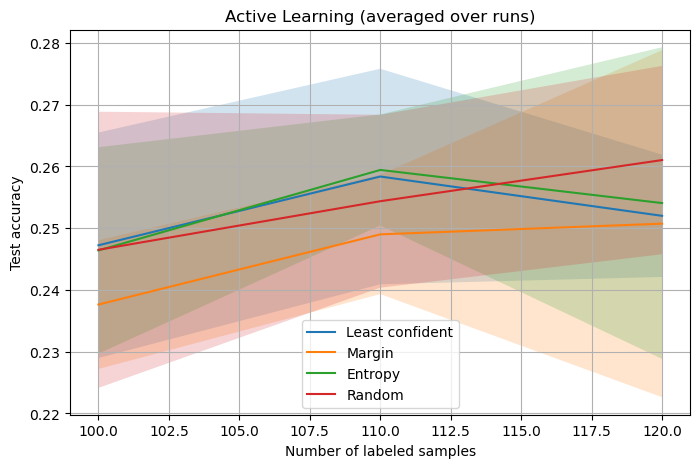

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 3          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 3

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=10,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()


Running averaged experiment: Least confident
  Run 1/3

=== Iteration 1/5 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/10  Loss: 4.635
Epoch 2/10  Loss: 4.524
Epoch 3/10  Loss: 4.366
Epoch 4/10  Loss: 4.079
Epoch 5/10  Loss: 3.914
Epoch 6/10  Loss: 3.704
Epoch 7/10  Loss: 3.410
Epoch 8/10  Loss: 3.020
Epoch 9/10  Loss: 2.960
Epoch 10/10  Loss: 2.695
Test accuracy: 0.2437

=== Iteration 2/5 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/10  Loss: 4.602
Epoch 2/10  Loss: 4.406
Epoch 3/10  Loss: 4.246
Epoch 4/10  Loss: 3.868
Epoch 5/10  Loss: 3.622
Epoch 6/10  Loss: 3.393
Epoch 7/10  Loss: 3.404
Epoch 8/10  Loss: 3.076
Epoch 9/10  Loss: 2.952
Epoch 10/10  Loss: 2.627
Test accuracy: 0.2444

=== Iteration 3/5 ===
Labeled set size: 120
Pool size:        49880
Epoch 1/10  Loss: 4.639
Epoch 2/10  Loss: 4.537
Epoch 3/10  Loss: 4.384
Epoch 4/10  Loss: 4.134
Epoch 5/10  Loss: 3.777
Epoch 6/10  Loss: 3.566
Epoch 7/10  Loss: 3.477
Epoch 8/10  Loss: 3.219
Epoch 9/10  Loss: 2

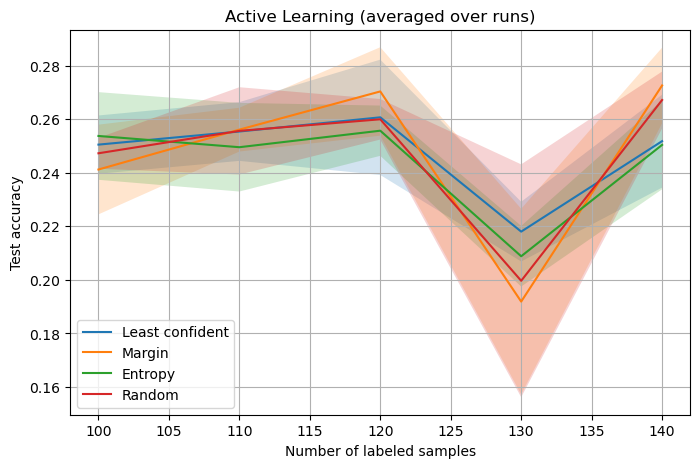

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 3          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 5

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=10,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()


Running averaged experiment: Least confident
  Run 1/3

=== Iteration 1/5 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/25  Loss: 4.662
Epoch 2/25  Loss: 4.530
Epoch 3/25  Loss: 4.442
Epoch 4/25  Loss: 4.229
Epoch 5/25  Loss: 4.007
Epoch 6/25  Loss: 3.712
Epoch 7/25  Loss: 3.450
Epoch 8/25  Loss: 3.109
Epoch 9/25  Loss: 3.198
Epoch 10/25  Loss: 2.948
Epoch 11/25  Loss: 2.498
Epoch 12/25  Loss: 2.563
Epoch 13/25  Loss: 2.374
Epoch 14/25  Loss: 2.027
Epoch 15/25  Loss: 1.846
Epoch 16/25  Loss: 1.612
Epoch 17/25  Loss: 1.475
Epoch 18/25  Loss: 1.255
Epoch 19/25  Loss: 1.121
Epoch 20/25  Loss: 1.107
Epoch 21/25  Loss: 0.869
Epoch 22/25  Loss: 0.808
Epoch 23/25  Loss: 0.568
Epoch 24/25  Loss: 0.537
Epoch 25/25  Loss: 0.514
Test accuracy: 0.2379

=== Iteration 2/5 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/25  Loss: 4.608
Epoch 2/25  Loss: 4.474
Epoch 3/25  Loss: 4.294
Epoch 4/25  Loss: 3.999
Epoch 5/25  Loss: 3.807
Epoch 6/25  Loss: 3.534
Epoch 7/25  Loss: 3.489


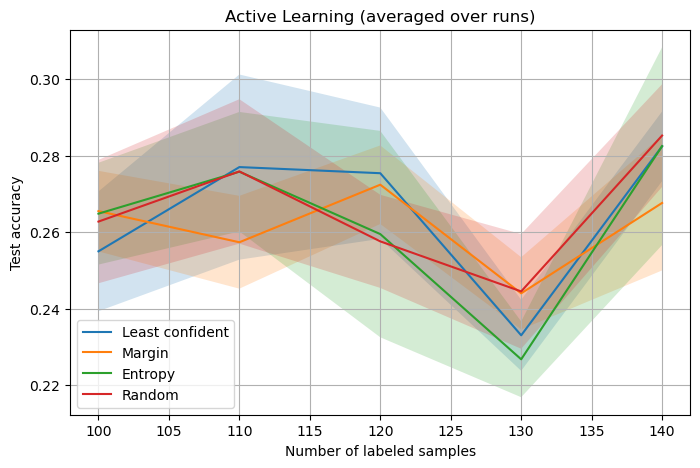

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 3          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 5

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=25,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()


Running averaged experiment: Least confident
  Run 1/3

=== Iteration 1/10 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/25  Loss: 4.649
Epoch 2/25  Loss: 4.523
Epoch 3/25  Loss: 4.371
Epoch 4/25  Loss: 4.244
Epoch 5/25  Loss: 3.929
Epoch 6/25  Loss: 3.613
Epoch 7/25  Loss: 3.538
Epoch 8/25  Loss: 3.121
Epoch 9/25  Loss: 3.152
Epoch 10/25  Loss: 3.098
Epoch 11/25  Loss: 2.706
Epoch 12/25  Loss: 2.519
Epoch 13/25  Loss: 2.255
Epoch 14/25  Loss: 2.093
Epoch 15/25  Loss: 1.830
Epoch 16/25  Loss: 1.541
Epoch 17/25  Loss: 1.598
Epoch 18/25  Loss: 1.289
Epoch 19/25  Loss: 1.054
Epoch 20/25  Loss: 1.137
Epoch 21/25  Loss: 0.888
Epoch 22/25  Loss: 0.957
Epoch 23/25  Loss: 0.512
Epoch 24/25  Loss: 0.566
Epoch 25/25  Loss: 0.464
Test accuracy: 0.2610

=== Iteration 2/10 ===
Labeled set size: 110
Pool size:        49890
Epoch 1/25  Loss: 4.649
Epoch 2/25  Loss: 4.511
Epoch 3/25  Loss: 4.316
Epoch 4/25  Loss: 4.083
Epoch 5/25  Loss: 3.740
Epoch 6/25  Loss: 3.427
Epoch 7/25  Loss: 3.29

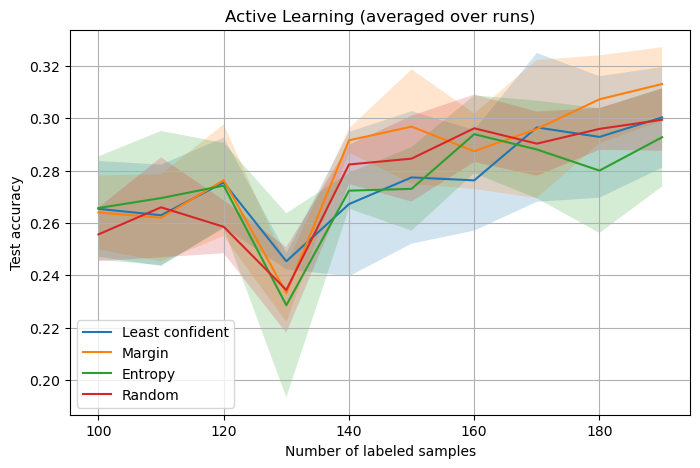

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 3          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 10

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=25,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()


Running averaged experiment: Least confident
  Run 1/3

=== Iteration 1/10 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/100  Loss: 4.660
Epoch 2/100  Loss: 4.491
Epoch 3/100  Loss: 4.376
Epoch 4/100  Loss: 4.162
Epoch 5/100  Loss: 3.951
Epoch 6/100  Loss: 3.634
Epoch 7/100  Loss: 3.506
Epoch 8/100  Loss: 3.354
Epoch 9/100  Loss: 2.986
Epoch 10/100  Loss: 2.939
Epoch 11/100  Loss: 2.777
Epoch 12/100  Loss: 2.413
Epoch 13/100  Loss: 2.326
Epoch 14/100  Loss: 2.039
Epoch 15/100  Loss: 2.083
Epoch 16/100  Loss: 1.633
Epoch 17/100  Loss: 1.693
Epoch 18/100  Loss: 1.180
Epoch 19/100  Loss: 1.261
Epoch 20/100  Loss: 0.907
Epoch 21/100  Loss: 0.801
Epoch 22/100  Loss: 0.886
Epoch 23/100  Loss: 0.739
Epoch 24/100  Loss: 0.575
Epoch 25/100  Loss: 0.424
Epoch 26/100  Loss: 0.436
Epoch 27/100  Loss: 0.338
Epoch 28/100  Loss: 0.443
Epoch 29/100  Loss: 0.285
Epoch 30/100  Loss: 0.349
Epoch 31/100  Loss: 0.317
Epoch 32/100  Loss: 0.229
Epoch 33/100  Loss: 0.292
Epoch 34/100  Loss: 0.149

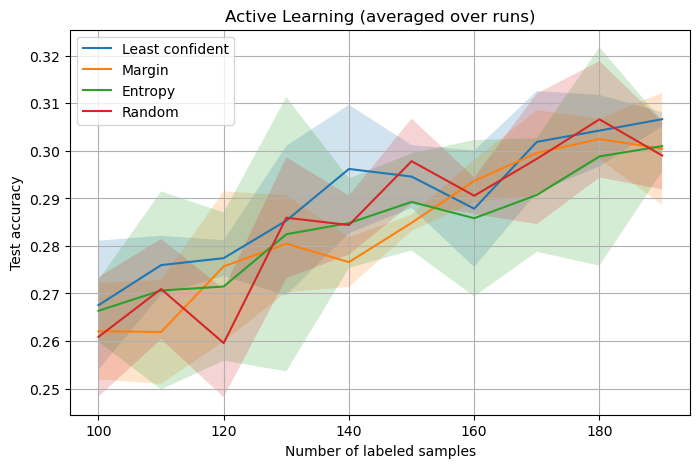

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 3          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 10

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=100,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()


Running averaged experiment: Least confident
  Run 1/5

=== Iteration 1/10 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/100  Loss: 4.613
Epoch 2/100  Loss: 4.507
Epoch 3/100  Loss: 4.307
Epoch 4/100  Loss: 3.936
Epoch 5/100  Loss: 3.602
Epoch 6/100  Loss: 3.474
Epoch 7/100  Loss: 3.325
Epoch 8/100  Loss: 3.167
Epoch 9/100  Loss: 2.805
Epoch 10/100  Loss: 2.746
Epoch 11/100  Loss: 2.477
Epoch 12/100  Loss: 2.242
Epoch 13/100  Loss: 1.804
Epoch 14/100  Loss: 1.839
Epoch 15/100  Loss: 1.525
Epoch 16/100  Loss: 1.367
Epoch 17/100  Loss: 1.420
Epoch 18/100  Loss: 0.954
Epoch 19/100  Loss: 0.892
Epoch 20/100  Loss: 0.847
Epoch 21/100  Loss: 0.589
Epoch 22/100  Loss: 0.718
Epoch 23/100  Loss: 0.484
Epoch 24/100  Loss: 0.597
Epoch 25/100  Loss: 0.269
Epoch 26/100  Loss: 0.402
Epoch 27/100  Loss: 0.428
Epoch 28/100  Loss: 0.212
Epoch 29/100  Loss: 0.263
Epoch 30/100  Loss: 0.222
Epoch 31/100  Loss: 0.180
Epoch 32/100  Loss: 0.112
Epoch 33/100  Loss: 0.121
Epoch 34/100  Loss: 0.077

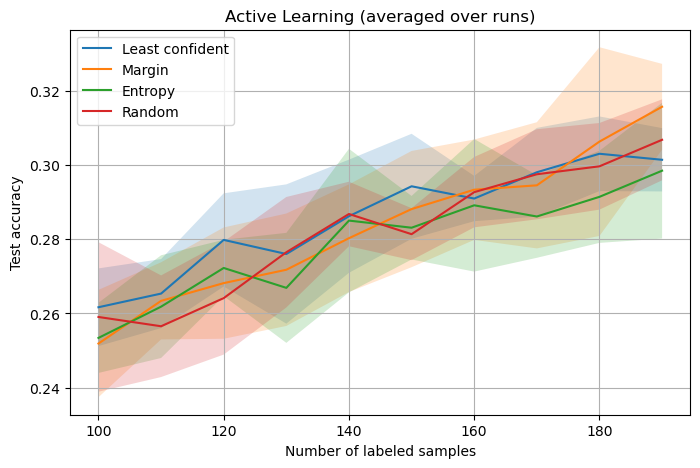

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 5          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 10

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=100,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()


Running averaged experiment: Least confident
  Run 1/5

=== Iteration 1/10 ===
Labeled set size: 100
Pool size:        49900
Epoch 1/100  Loss: 4.656
Epoch 2/100  Loss: 4.507
Epoch 3/100  Loss: 4.285
Epoch 4/100  Loss: 4.074
Epoch 5/100  Loss: 3.755
Epoch 6/100  Loss: 3.537
Epoch 7/100  Loss: 3.498
Epoch 8/100  Loss: 3.249
Epoch 9/100  Loss: 3.046
Epoch 10/100  Loss: 2.915
Epoch 11/100  Loss: 2.691
Epoch 12/100  Loss: 2.537
Epoch 13/100  Loss: 2.373
Epoch 14/100  Loss: 2.117
Epoch 15/100  Loss: 1.811
Epoch 16/100  Loss: 1.854
Epoch 17/100  Loss: 1.438
Epoch 18/100  Loss: 1.376
Epoch 19/100  Loss: 1.149
Epoch 20/100  Loss: 0.847
Epoch 21/100  Loss: 0.839
Epoch 22/100  Loss: 0.752
Epoch 23/100  Loss: 0.689
Epoch 24/100  Loss: 0.568
Epoch 25/100  Loss: 0.470
Epoch 26/100  Loss: 0.396
Epoch 27/100  Loss: 0.357
Epoch 28/100  Loss: 0.286
Epoch 29/100  Loss: 0.178
Epoch 30/100  Loss: 0.214
Epoch 31/100  Loss: 0.131
Epoch 32/100  Loss: 0.186
Epoch 33/100  Loss: 0.192
Epoch 34/100  Loss: 0.144

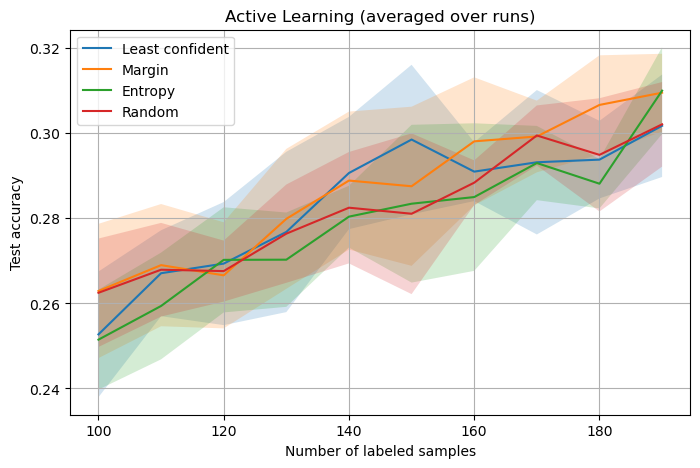

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from active_learning import run_active_learning

# Settings
n_avg = 5          # start small (e.g. 5), increase later (e.g. 20+)
n_iterations = 10

common_kwargs = dict(
    data_dir="data/cifar-10-batches-py",
    n_initial_per_class=10,
    n_iterations=n_iterations,
    query_size=10,
    batch_size=64,
    epochs=100,
    lr=1e-3,
)

experiments = {
    "Least confident": {"paradigm": "active learning", "strategy": "least confident"},
    "Margin": {"paradigm": "active learning", "strategy": "margin"},
    "Entropy": {"paradigm": "active learning", "strategy": "entropy"},
    "Random": {"paradigm": "random"},
}

results = {}

for name, settings in experiments.items():
    print(f"\nRunning averaged experiment: {name}")

    all_scores = []

    for i in range(n_avg):
        print(f"  Run {i+1}/{n_avg}")

        scores, labeled_sizes, _, _ = run_active_learning(
            **common_kwargs,
            **settings,
            seed=i   # IMPORTANT: different seed each run
        )

        all_scores.append(scores)

    all_scores = np.array(all_scores)

    results[name] = {
        "mean": all_scores.mean(axis=0),
        "std": all_scores.std(axis=0),
        "labeled_sizes": labeled_sizes
    }


plt.figure(figsize=(8, 5))

for name, res in results.items():
    mean = res["mean"]
    std = res["std"]
    x = res["labeled_sizes"]

    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning (averaged over runs)")
plt.legend()
plt.grid(True)
plt.show()